# Mid-Term Practical Evaluation — Machine Learning

**Universidad Internacional del Ecuador — Computer Science School**
**Duration:** 90 minutes · **Modality:** Individual · **Total:** 12 points

---

## Before You Start

1. Confirm the Codespace finished building (no red error in the bottom bar).
2. Read **all 11 tasks first** before writing any code. The rubric tells you where the points are.
3. Save the notebook every 10 minutes (`Cmd/Ctrl + S`).
4. Commit at the end of each Part. If something breaks, you still have credit for what worked.
5. **AI assistants are not allowed.** Open notes, slides, sklearn/pandas docs are allowed.


---
# PART A — Setup & Diagnostics (2.5 pts, ~20 min)


## Task 1 — Environment check (0.5 pts)

Run the cell below. If you see version numbers printed, you are ready.

In [8]:
import sys
import pandas as pd
import sklearn
import numpy as np

print(f"Python ......... {sys.version.split()[0]}")
print(f"pandas ......... {pd.__version__}")
print(f"scikit-learn ... {sklearn.__version__}")
print(f"numpy .......... {np.__version__}")
print("\nEnvironment OK — you can proceed.")


Python ......... 3.12.13
pandas ......... 3.0.3
scikit-learn ... 1.8.0
numpy .......... 2.4.4

Environment OK — you can proceed.


## Task 2 — Fix the bug in `src/scale.py` (1 pt)

The function `min_max_scale()` in `src/scale.py` currently produces values in the range `[-1, 0]` instead of `[0, 1]`.

**What to do:**
1. Open `src/scale.py` (use the VS Code file tree on the left).
2. Find the bug. Fix it.
3. Add a **one-line comment** above your fix explaining what was wrong.
4. Run the verification cell below. It must print `Bug fix verified: OK`.

In [9]:
# Verification cell — do not modify
import importlib
from src import scale
importlib.reload(scale)
import numpy as np

test_data = np.array([10, 20, 30, 40, 50])
scaled = scale.min_max_scale(test_data)

assert scaled.min() == 0.0, f"min should be 0, got {scaled.min()}"
assert scaled.max() == 1.0, f"max should be 1, got {scaled.max()}"
print(f"Scaled output: {scaled}")
print("Bug fix verified: OK")


Scaled output: [0.   0.25 0.5  0.75 1.  ]
Bug fix verified: OK


## Task 3 — Pandas indexing (1 pt)

A small DataFrame `df_small` is provided below. In the next cell:

- **(0.5 pt)** Print the dtype of the `category` column. Then add a comment briefly stating whether it is `object`, `category`, or `CategoricalDtype`, and why.
- **(0.5 pt)** Using **label-based indexing** (not position-based), retrieve the value at row index `3`, column `alcohol`, and assign it to a variable named `target_value`. Then print it.

In [10]:
import pandas as pd

df_small = pd.DataFrame({
    "alcohol":   [9.5, 10.2, 11.0, 12.8, 9.9],
    "ph":        [3.4, 3.2, 3.5, 3.1, 3.3],
    "category":  pd.Categorical(["train", "train", "test", "test", "train"]),
})
df_small


,alcohol,ph,category
0,9.5,3.4,train
1,10.2,3.2,train
2,11.0,3.5,test
3,12.8,3.1,test
4,9.9,3.3,train


In [11]:
# TODO Task 3a: print the dtype of the 'category' column.
# Then add a comment explaining what it is and why.
print(df_small["category"].dtype)


# TODO Task 3b: use label-based indexing to retrieve the value at
# row index 3, column 'alcohol', and assign it to target_value.
target_value = df_small.loc[3, "alcohol"]
print(f"target_value = {target_value}")

category
target_value = 12.8


---
# PART B — Linear Regression (5 pts, ~35 min)


## Load the dataset

Run the cell below to load the wine quality dataset. **Do not modify it.**

In [13]:
import pandas as pd
df = pd.read_csv("/workspaces/evaluacion-final-u2-ml/data/wine_quality.csv")
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Loaded 1599 rows and 12 columns.


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,8.85,0.682,0.193,1.62,0.029,23.1,36.1,0.99637,3.27,0.42,9.87,4
1,6.51,0.449,0.254,1.24,0.134,19.5,56.8,0.99660,3.22,0.65,9.93,6
2,9.63,0.453,0.573,2.67,0.054,1.9,49.6,0.99480,3.34,0.86,10.51,6
3,9.96,0.535,0.186,2.77,0.133,26.0,24.6,0.99389,3.34,0.86,8.93,5
4,4.93,0.628,0.180,1.31,0.029,24.9,63.1,0.99679,3.38,0.83,8.97,5


## Task 4 — Quick EDA (1 pt)

Produce **exactly two** plots in the cell below:
1. Distribution of the target `quality` (histogram or bar chart).
2. Correlation heatmap of all numeric features against `quality` (you may use `seaborn.heatmap`).

Then, in the markdown cell that follows, write **two sentences**:
- (a) Which feature has the strongest correlation with `quality`?
- (b) One data issue you noticed (missing values, skew, outliers, scale differences, class imbalance — pick one and name it).

/tmp/ipykernel_20446/465962645.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, ax=axes[0], palette="viridis")


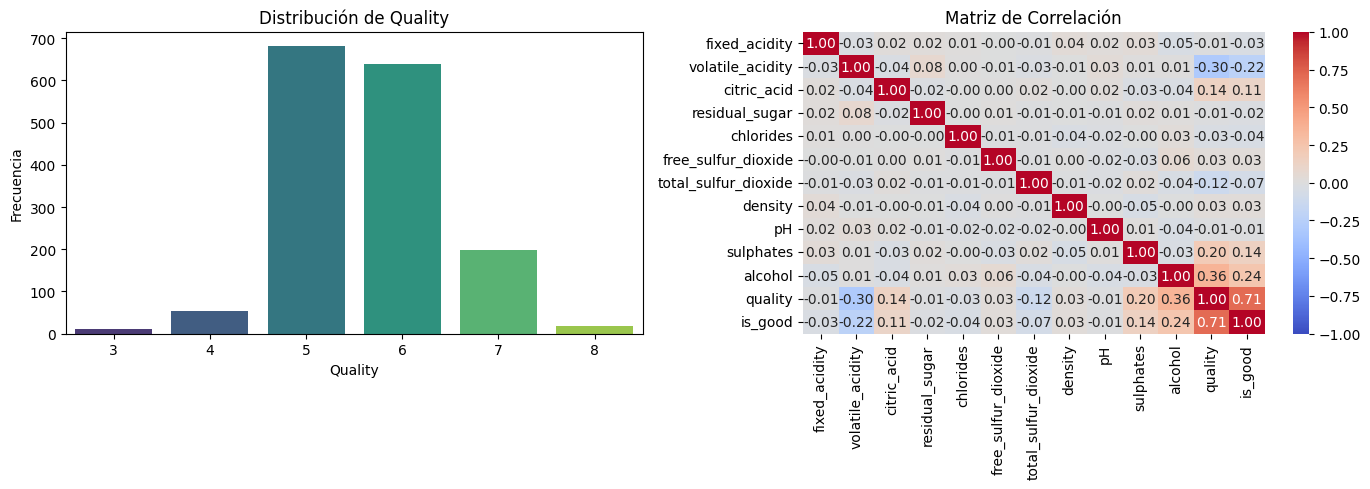

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO Task 4: produce the two required plots here.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribución del target 'quality'
sns.countplot(x="quality", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Distribución de Quality")
axes[0].set_xlabel("Quality")
axes[0].set_ylabel("Frecuencia")
# Plot 2: Heatmap de correlación
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
 ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Matriz de Correlación")
plt.tight_layout()
plt.show()


**Your two-sentence observation goes here:**

- (a) alcohol parece ser la característica más asociada con quality, y su correlación positiva indica que valores más altos de alcohol suelen estar relacionados con mejores calificaciones.
- (b) El conjunto de datos no está distribuido uniformemente: predominan las clases 5 y 6, mientras que las clases extremas aparecen con muy poca frecuencia.


## Task 5 — Preprocessing Pipeline (2 pts)

Build a Scikit-learn `Pipeline` with:
- A scaler (`StandardScaler` or `MinMaxScaler` — your choice, **justify in a comment**)
- `LinearRegression` as the final estimator

Then split the data **80/20** with `random_state=42`. **Only fit the Pipeline on the training set.** Any leakage between train and test costs you the full 2 points.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler  # or MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# TODO Task 5:
# 1. Define X (all features except 'quality') and y (the 'quality' column).
X = df.drop(columns=["quality"])
y = df["quality"]
# 2. Build the Pipeline. Add a comment justifying your scaler choice.
pipe_lr = Pipeline([
 ("scaler", StandardScaler()),
 ("regressor", LinearRegression())
])
# 3. Split 80/20 with random_state=42.
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.2,
 random_state=42
)
# 4. Fit the Pipeline on the training set only.
pipe_lr.fit(X_train, y_train)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print("Pipeline fitted on training set only ✔")


Train: 1279 filas | Test: 320 filas
Pipeline fitted on training set only ✔


## Task 6 — Train & evaluate linear regression (2 pts)

On the **test set**, compute and print three metrics:
- R² (`r2_score`)
- MAE (`mean_absolute_error`)
- RMSE (square root of `mean_squared_error`)

Then, in the markdown cell that follows, write **one sentence**: is the model usable? Reference one of the three metrics to justify.

In [22]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# TODO Task 6: predict on the test set, then print R², MAE, RMSE.

y_pred = pipe_lr.predict(X_test)
# Calcular métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² = {r2:.4f}")
print(f"MAE = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")


R² = 0.3162
MAE = 0.5365
RMSE = 0.6726


**Your one-sentence interpretation:**

*…*


---
# PART C — Logistic Regression (4 pts, ~25 min)


## Task 7 — Engineer a binary target (0.5 pts)

Create a new column `is_good` in `df` defined as `1` if `quality >= 7`, else `0`.

In a comment, state how many samples fall in each class. This matters for Task 9.

In [19]:
# TODO Task 7: create df['is_good'] and report class counts.

df["is_good"] = (df["quality"] >= 7).astype(int)

# Check the number of observations in each binary class.
print(df["is_good"].value_counts())

# Class distribution:
# 0 -> 1382 wines are not classified as good because quality is below 7.
# 1 -> 217 wines are classified as good because quality is 7 or higher.
# This shows an imbalanced target: the positive class represents only about 13.6% of the dataset.
# Because class 1 has fewer samples, the classifier may struggle more to identify good wines correctly.

is_good
0    1382
1     217
Name: count, dtype: int64


## Task 8 — Train logistic regression with L2 (2 pts)

Build a **second Pipeline** for classification:
- Same scaler as Part B
- `LogisticRegression` with **L2 regularization** (confirm in a comment that L2 is the default) and `max_iter=1000`

Re-split the data 80/20 with `random_state=42` for the new binary target.

On the **test set**, print:
- Accuracy
- F1 score (binary)
- ROC-AUC (use `predict_proba`)
- The Confusion Matrix

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Separate the predictors from the binary target created in the previous task.
X_cls = df.drop(columns=["quality", "is_good"])
y_cls = df["is_good"]

# Create the training and testing sets using the required 80/20 split.
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

# Build the classification pipeline using the same scaler from the regression part.
# LogisticRegression uses L2 regularization by default; it is written here explicitly for clarity.
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l2", max_iter=1000, random_state=42))
])

# Train only with the training data to avoid data leakage.
log_reg_pipeline.fit(X_train_cls, y_train_cls)

# Generate class predictions and probabilities for the positive class.
y_pred_cls = log_reg_pipeline.predict(X_test_cls)
y_prob_cls = log_reg_pipeline.predict_proba(X_test_cls)[:, 1]

# Evaluate the classifier on the test set.
accuracy = accuracy_score(y_test_cls, y_pred_cls)
f1_binary = f1_score(y_test_cls, y_pred_cls)
auc_score = roc_auc_score(y_test_cls, y_prob_cls)
conf_matrix = confusion_matrix(y_test_cls, y_pred_cls)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 score: {f1_binary:.4f}")
print(f"ROC-AUC: {auc_score:.4f}")
print("\nConfusion matrix:")
print(conf_matrix)

Accuracy: 0.8625
F1 score: 0.2414
ROC-AUC: 0.8090

Confusion matrix:
[[269   6]
 [ 38   7]]


/app/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Task 9 — Interpret class imbalance (1 pt)

In the markdown cell below, write **two sentences**:
- (a) Which class is harder to predict (good wines, label 1, or non-good wines, label 0)?
- (b) What does the confusion matrix tell you about *why*?

**Your answer:**

- (a) La clase 1 es la más complicada para el modelo, ya que los vinos buenos aparecen con poca frecuencia dentro del dataset. Por esa razón, el clasificador se inclina más hacia la clase 0, que es la categoría dominante.
- (b) En la matriz de confusión se observa que el modelo deja pasar varios casos positivos como si fueran negativos. Esto significa que puede verse bien en accuracy, pero no necesariamente está detectando bien los vinos de buena calidad.

---
# PART D — Reflection & Submit (1 pt, ~10 min)


## Task 10 — Written reflection (0.5 pts)

In **3–5 sentences**, answer:

> If you had one more hour with this dataset, what would you change first, and why? Reference at least one concept from class (e.g., learning rate, outliers, regularization strength `C`, class imbalance, feature engineering, gradient descent behavior, train/test split strategy).

Generic answers like "I would improve the model" earn zero points. Be specific.

**Your reflection:**

*Si tuviera una hora más con este dataset, primero trabajaría en el desbalance de clases del modelo de clasificación binaria. La clase positiva (is_good = 1) tiene muchas menos muestras que la clase negativa, por lo que el modelo puede lograr una buena accuracy aunque no detecte bien los vinos buenos. Probaría estrategias como class_weight="balanced" en Logistic Regression y volvería a comparar el F1 score y la matriz de confusión. También intentaría hacer feature engineering, porque la calidad del vino puede depender de combinaciones de variables y no solo de relaciones lineales individuales.*


## Task 11 — Commit, push, submit (0.5 pts)

In the Codespaces terminal:

```bash
git add .
git commit -m "Final exam submission"
git push
```

Then paste your repository URL in Canvas before the 90-minute timer expires.

**Late submissions are not accepted.** The Git commit timestamp is the official submission time.
